In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import missingno as msno

In [16]:
df = pd.read_csv('C:/Users/frndas/Downloads/hotel_bookings.csv')

# EDA &Data Cleaning

In [4]:
df.head(15)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,0,2015,July,27,1,0,2,2,...,No Deposit,NaN,NaN,0,Transient,107.00,0,0,Check-Out,2015-07-03
7,Resort Hotel,0,9,2015,July,27,1,0,2,2,...,No Deposit,303.0,NaN,0,Transient,103.00,0,1,Check-Out,2015-07-03
8,Resort Hotel,1,85,2015,July,27,1,0,3,2,...,No Deposit,240.0,NaN,0,Transient,82.00,0,1,Canceled,2015-05-06
9,Resort Hotel,1,75,2015,July,27,1,0,3,2,...,No Deposit,15.0,NaN,0,Transient,105.50,0,0,Canceled,2015-04-22


In [5]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [6]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [9]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

Handling Missing Values

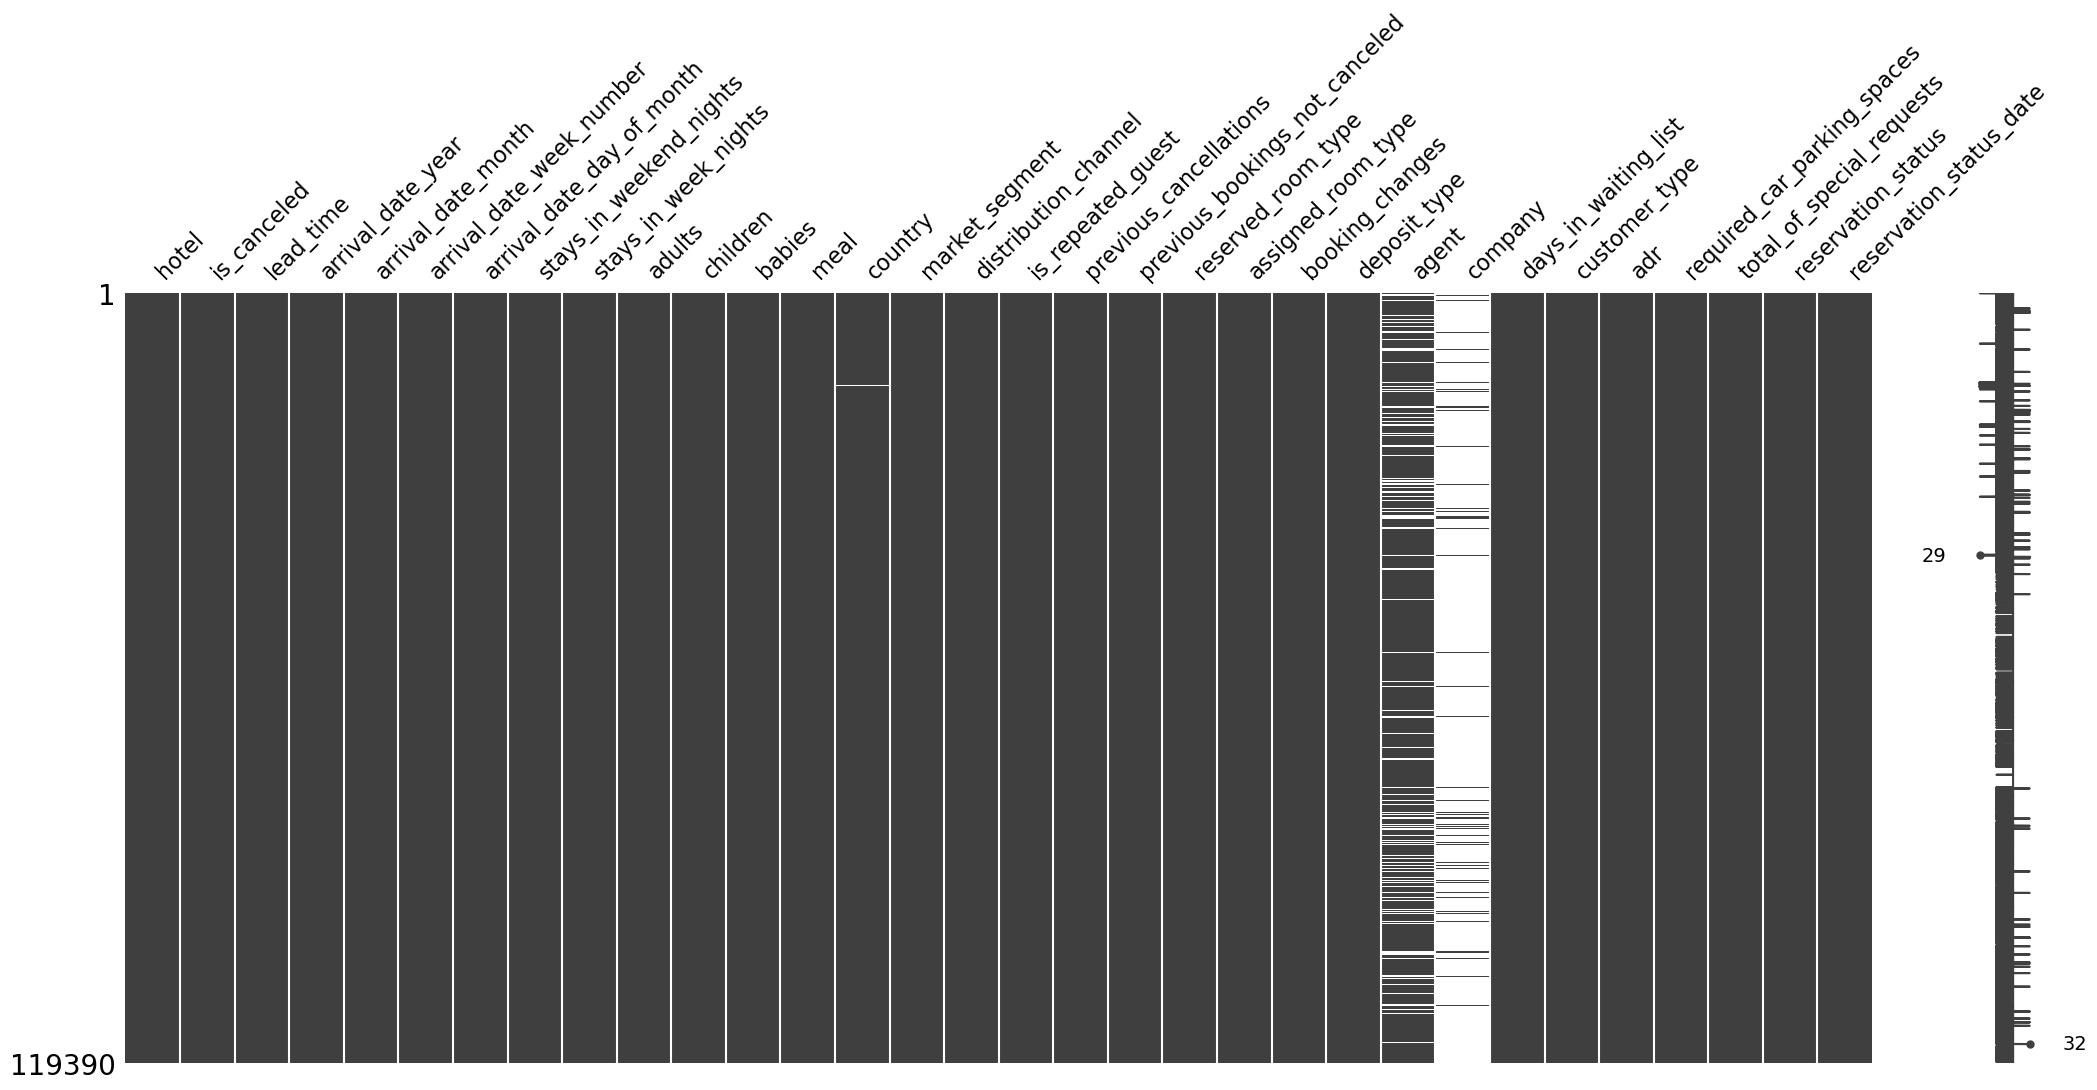

In [13]:
# Visualize missing values
msno.matrix(df)
plt.show()


In [17]:
df = df.drop("company", axis=1)


In [18]:
df['agent'] = df['agent'].fillna(0)
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['children'] = df['children'].fillna(df['children'].median())


Drop duplicates

In [19]:
df = df.drop_duplicates()


Outliers

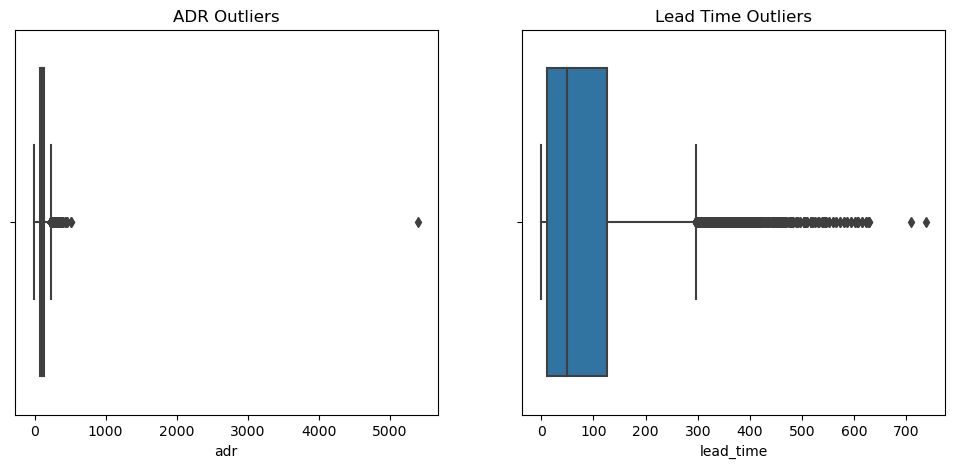

In [20]:
# Outlier detection
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(x=df['adr'], ax=axes[0])
axes[0].set_title("ADR Outliers")
sns.boxplot(x=df['lead_time'], ax=axes[1])
axes[1].set_title("Lead Time Outliers")
plt.show()

In [21]:
# IQR method for adr
Q1 = df['adr'].quantile(0.25)
Q3 = df['adr'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['adr'] < Q1 - 1.5*IQR) | (df['adr'] > Q3 + 1.5*IQR)]
print("ADR Outliers count:", len(outliers))

ADR Outliers count: 2488


In [22]:
df['adr'] = np.where(df['adr'] > 1000, 1000, df['adr'])


Data Types

In [23]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])


(( Now we're done of exploring data and cleaning it ))

# Data Visualization

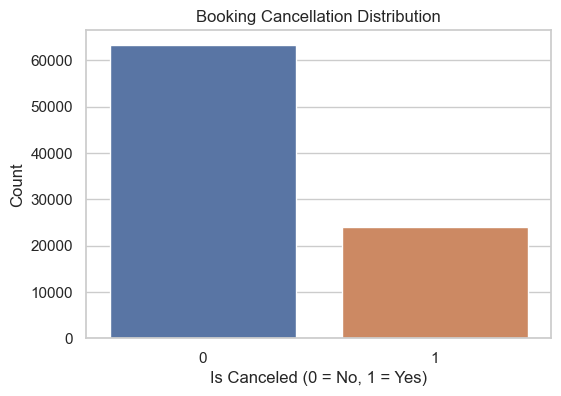

In [26]:
sns.set(style="whitegrid")
# 1. Distribution of target variable (is_canceled)
plt.figure(figsize=(6,4))
sns.countplot(x="is_canceled", data=df)
plt.title("Booking Cancellation Distribution")
plt.xlabel("Is Canceled (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

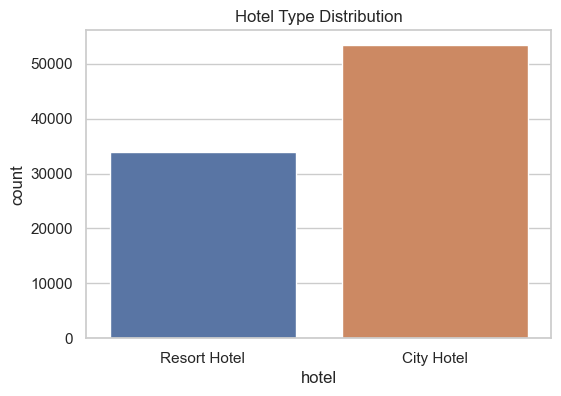

In [27]:
# 2. Hotel type distribution
plt.figure(figsize=(6,4))
sns.countplot(x="hotel", data=df)
plt.title("Hotel Type Distribution")
plt.show()

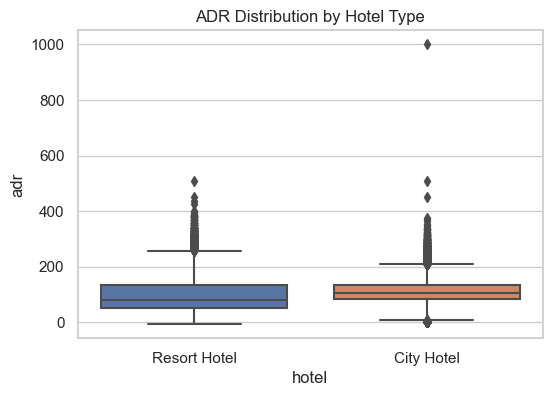

In [28]:
# 3. Average daily rate (adr) by hotel type
plt.figure(figsize=(6,4))
sns.boxplot(x="hotel", y="adr", data=df)
plt.title("ADR Distribution by Hotel Type")
plt.show()

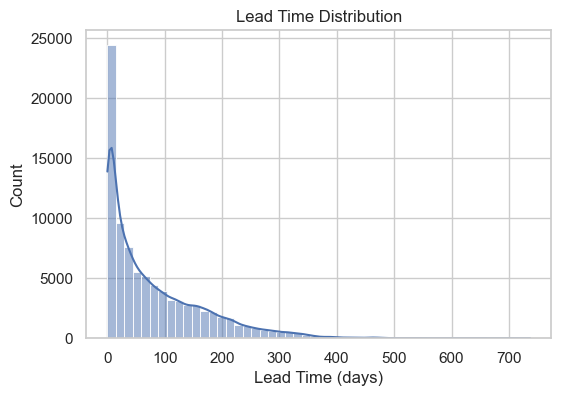

In [29]:
# 4. Lead time distribution
plt.figure(figsize=(6,4))
sns.histplot(df["lead_time"], bins=50, kde=True)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (days)")
plt.show()


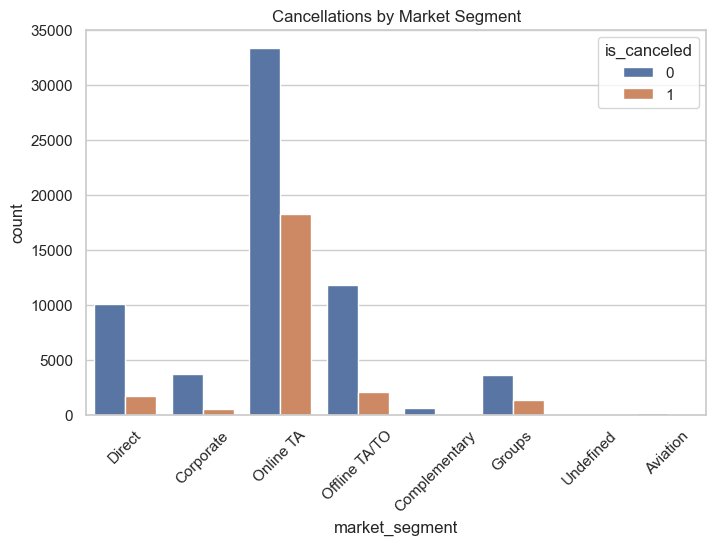

In [30]:
# 5. Cancellations by market segment
plt.figure(figsize=(8,5))
sns.countplot(x="market_segment", hue="is_canceled", data=df)
plt.title("Cancellations by Market Segment")
plt.xticks(rotation=45)
plt.show()

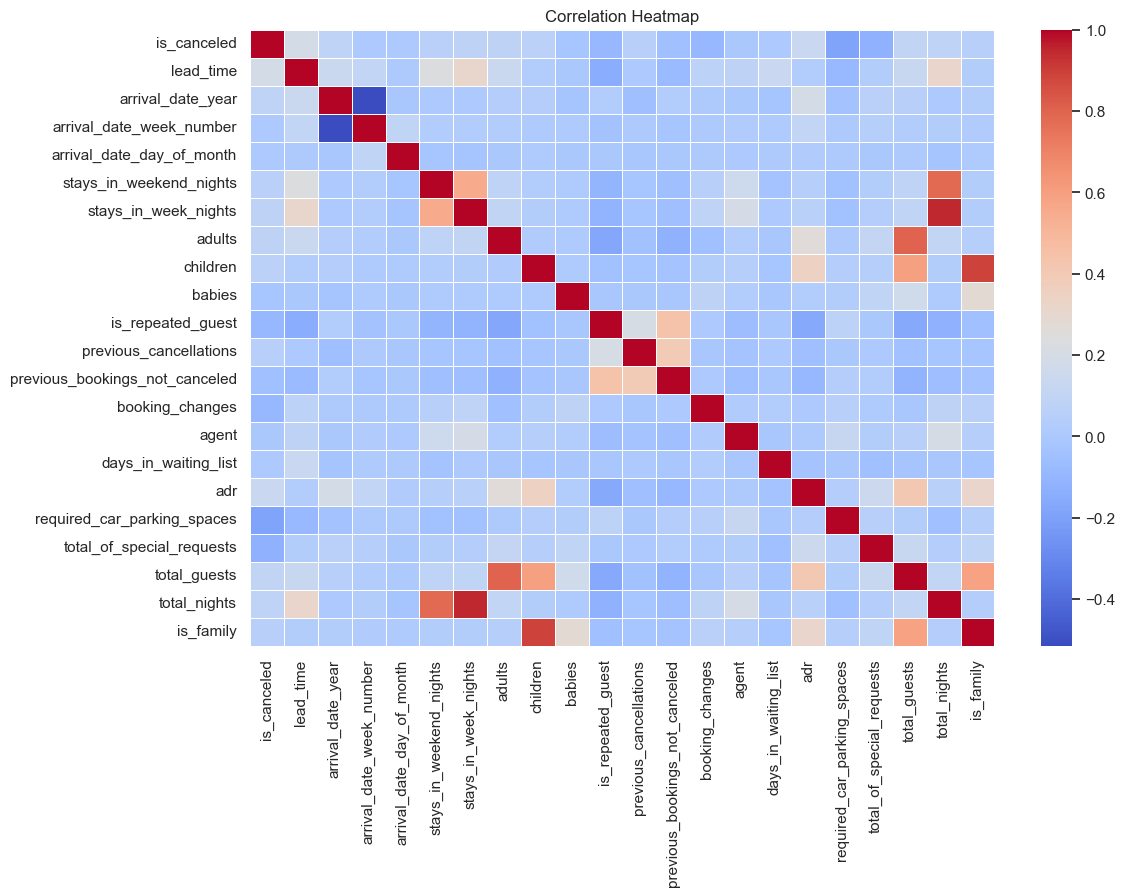

In [31]:
# 6. Correlation heatmap
plt.figure(figsize=(12,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", annot=False, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

#  Feature Engineering & Preprocessing

new features

In [24]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['is_family'] = np.where((df['children'] + df['babies']) > 0, 1, 0)


Drop leakage columns

In [25]:
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)


Encoding categorical variables

In [32]:
low_cardinality = ['meal', 'market_segment', 'distribution_channel', 'deposit_type']
df = pd.get_dummies(df, columns=low_cardinality, drop_first=True)


Frequency encoding for high-cardinality (country)

In [33]:
country_freq = df['country'].value_counts().to_dict()
df['country'] = df['country'].map(country_freq)


Train-test split

In [34]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)

print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (69896, 45)
Test shape: (17474, 45)


In [35]:
print("Final dataset ready for ML model.")
print("Number of features:", train.shape[1])
train.head()

Final dataset ready for ML model.
Number of features: 45


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,market_segment_Undefined,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,distribution_channel_Undefined,deposit_type_Non Refund,deposit_type_Refundable
33732,Resort Hotel,0,0,2017,March,9,1,0,1,3,...,False,False,False,False,True,False,False,False,False,False
100607,City Hotel,0,142,2016,October,44,27,0,3,2,...,False,False,False,False,True,False,False,False,False,False
85558,City Hotel,0,47,2016,March,12,14,1,3,2,...,False,False,True,False,False,False,True,False,False,False
6792,Resort Hotel,1,172,2016,July,27,2,2,5,2,...,False,False,True,False,False,False,True,False,False,False
47996,City Hotel,1,37,2016,March,11,11,2,2,1,...,False,False,True,False,False,False,True,False,False,False
